# Telehealth & Patient Engagement Analysis
### SQL analysis of telehealth adoption, follow-up adherence and no-show behaviour on a synthetic EHR

**Project 2 of the Health Data Analytics portfolio**

---

This notebook is deliberately thin: the analysis lives in the ten SQL files under `sql/queries/`. The notebook
runs each query against `telehealth.db`, shows the result and charts the ones that carry the story.

| Section | Question | Query |
|---|---|---|
| 1 | How fast did telehealth take off, and where did it settle? | `01_telehealth_adoption_by_year` |
| 2 | Who uses it: age groups | `02_adoption_by_age_group` |
| 3 | Who uses it: chronic conditions | `03_telehealth_by_condition` |
| 4 | What is it used for? | `04_visit_reasons_by_modality` |
| 5 | Do virtual visits reduce no-shows? | `05_no_show_rates`, `06_no_show_drivers` |
| 6 | Do patients get follow-up after an emergency or inpatient stay? | `07_post_acute_followup` |
| 7 | Are chronic patients seen on cadence, and does telehealth use go with it? | `08_chronic_care_cadence` |
| 8 | Engagement by age group and condition | `09_engagement_by_age_and_condition` |
| 9 | Do first-time telehealth users come back? | `10_telehealth_persistence` |

The database is built from a Synthea synthetic cohort (1,500 living Massachusetts patients, 2019-2025) with a
documented simulation layer for visit modality and appointment no-shows; see the README and `build_database.py`.

In [1]:
import sqlite3
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

DB = Path("telehealth.db")
SQL_DIR = Path("sql/queries")
FIG_DIR = Path("figures"); FIG_DIR.mkdir(exist_ok=True)

# --- Chart theme (same system as project 1): teal = telehealth, warm orange = in person, recessive chrome ---
TEAL, ORANGE, NAVY = "#0f9d8a", "#e8892b", "#0b1f3a"
INK, MUTED, GRID = "#1f2933", "#52606d", "#e4e7eb"
MODALITY_COLORS = {"telehealth": TEAL, "in_person": ORANGE}
MODALITY_LABELS = {"telehealth": "Telehealth", "in_person": "In person"}
AGE_ORDER = ["0-17", "18-34", "35-49", "50-64", "65+"]

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight", "font.size": 10.5,
    "axes.edgecolor": GRID, "axes.labelcolor": INK, "axes.titlecolor": INK, "axes.titleweight": "bold",
    "axes.titlesize": 12, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8, "axes.axisbelow": True,
    "xtick.color": MUTED, "ytick.color": MUTED, "legend.frameon": False,
})

con = sqlite3.connect(DB)

def run(name: str) -> pd.DataFrame:
    """Run sql/queries/<name>.sql and return a DataFrame."""
    sql = (SQL_DIR / f"{name}.sql").read_text()
    return pd.read_sql(sql, con)

def finish(fig, name):
    fig.tight_layout()
    fig.savefig(FIG_DIR / name)
    plt.show()

pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)

## 0. The database

Eight tables plus two views. `encounters.modality` is the telehealth flag; `appointments` is the scheduling
layer with completed, no-show and cancelled bookings.

In [2]:
tables = ["patients", "encounters", "conditions", "medications", "appointments", "providers", "organizations", "payers"]
counts = pd.DataFrame({"table": tables,
                       "rows": [con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0] for t in tables]})
display(counts.set_index("table").T)

print(pd.read_sql("SELECT modality, encounter_class, COUNT(*) AS visits FROM encounters "
                  "GROUP BY 1, 2 ORDER BY 1, 3 DESC", con).to_string(index=False))

table,patients,encounters,conditions,medications,appointments,providers,organizations,payers
rows,1500,46524,39015,37882,52821,774,779,10


  modality encounter_class  visits
 in_person      ambulatory   22643
 in_person        wellness    9278
 in_person      outpatient    6469
 in_person      urgentcare    1647
 in_person       emergency    1612
 in_person       inpatient     340
 in_person            home     270
 in_person             snf     175
 in_person         hospice      39
telehealth      ambulatory    2967
telehealth      outpatient     765
telehealth         virtual     177
telehealth      urgentcare     142


## 1. Telehealth adoption over time

`01_telehealth_adoption_by_year.sql` — CTEs for yearly volume and first-use year, `LAG()` for the year-on-year
change in share, and a running `SUM() OVER (ORDER BY year)` for the cumulative user base.

In [3]:
q1 = run("01_telehealth_adoption_by_year")
q1

,visit_year,visits,telehealth_visits,telehealth_share_pct,share_change_pts,telehealth_patients,pct_active_patients_using_telehealth,new_telehealth_users,cumulative_telehealth_users
0,2019,5726,38,0.7,NaN,32,2.5,32,32
1,2020,5763,828,14.4,13.7,438,33.0,420,452
2,2021,7748,775,10.0,-4.4,413,29.6,213,665
3,2022,6501,614,9.4,-0.6,355,26.3,125,790
4,2023,6715,556,8.3,-1.2,332,24.5,92,882
5,2024,7031,642,9.1,0.9,341,24.7,76,958
6,2025,7040,598,8.5,-0.6,353,25.4,68,1026


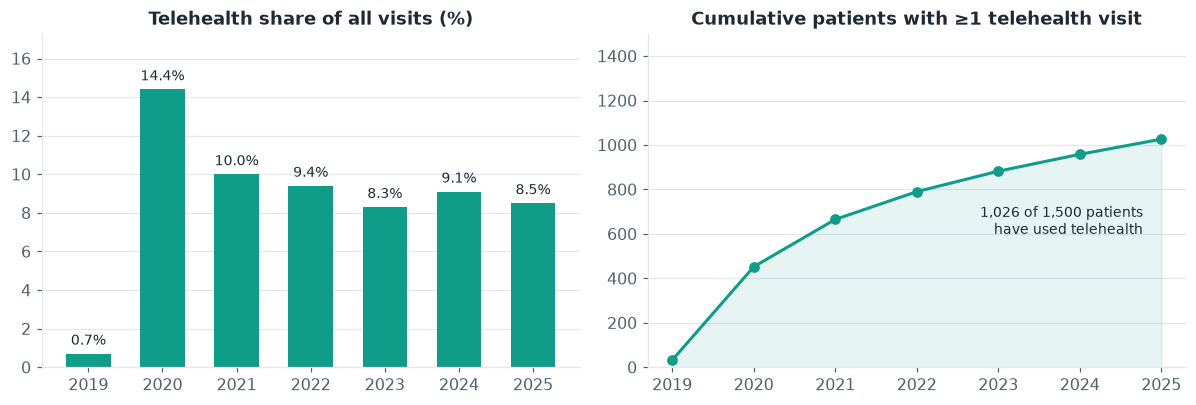

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
bars = ax.bar(q1.visit_year.astype(str), q1.telehealth_share_pct, color=TEAL, width=0.6)
for b, v in zip(bars, q1.telehealth_share_pct):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_title("Telehealth share of all visits (%)")
ax.set_ylim(0, q1.telehealth_share_pct.max() * 1.2); ax.grid(axis="x", visible=False)

ax = axes[1]
ax.plot(q1.visit_year, q1.cumulative_telehealth_users, color=TEAL, lw=2, marker="o", ms=6)
ax.fill_between(q1.visit_year, q1.cumulative_telehealth_users, color=TEAL, alpha=0.10)
last = q1.iloc[-1]
ax.annotate(f"{int(last.cumulative_telehealth_users):,} of 1,500 patients\nhave used telehealth",
            (last.visit_year, last.cumulative_telehealth_users), xytext=(-12, -62), textcoords="offset points",
            ha="right", color=INK, fontsize=9)
ax.set_title("Cumulative patients with ≥1 telehealth visit")
ax.set_ylim(0, 1500); ax.set_xticks(q1.visit_year); ax.grid(axis="x", visible=False)
finish(fig, "01_adoption_by_year.png")

Telehealth was negligible in 2019, jumped to about one visit in seven in 2020, then settled at roughly one in
eleven. The user base kept growing after the spike: most patients tried it once, fewer kept using it (section 9).

## 2. Adoption by age group

`02_adoption_by_age_group.sql` — steady-state window (2021-2025), `SUM() OVER ()` for the population benchmark and
`RANK()` for the adoption order. Two different measures of adoption are reported: share of *visits* that are
virtual (intensity) and share of *patients* who used telehealth at least once (reach).

In [5]:
q2 = run("02_adoption_by_age_group")
q2

,age_group,patients,visits,telehealth_visits,telehealth_share_pct,pct_patients_using_telehealth,overall_share_pct,diff_vs_overall_pts,adoption_rank
0,0-17,341,5074,309,6.1,42.2,9.1,-3.0,5
1,18-34,372,7754,798,10.3,69.6,9.1,1.2,2
2,35-49,279,6288,690,11.0,63.1,9.1,1.9,1
3,50-64,283,7841,725,9.2,70.3,9.1,0.2,3
4,65+,225,8078,663,8.2,66.2,9.1,-0.9,4


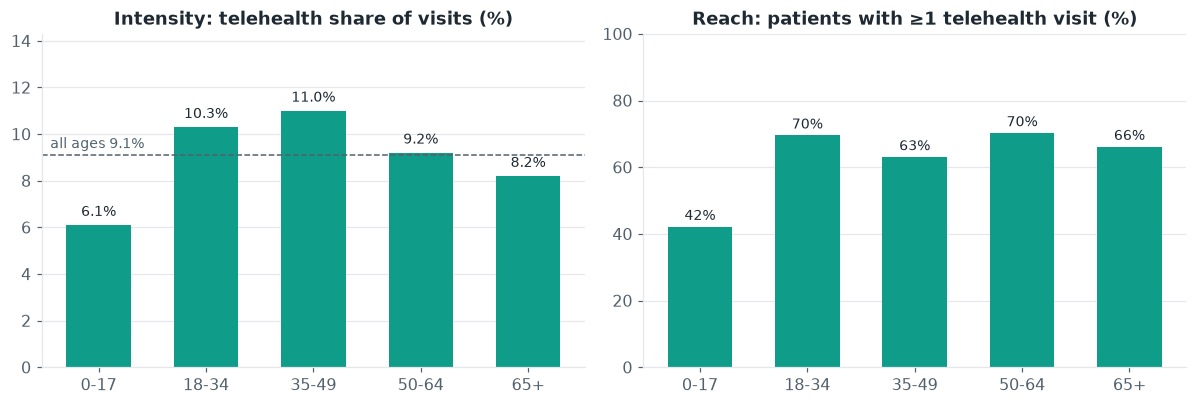

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8), sharey=False)
x = np.arange(len(AGE_ORDER)); d = q2.set_index("age_group").loc[AGE_ORDER]

ax = axes[0]
bars = ax.bar(x, d.telehealth_share_pct, color=TEAL, width=0.6)
ax.axhline(d.overall_share_pct.iloc[0], color=MUTED, lw=1, ls="--")
ax.text(-0.45, d.overall_share_pct.iloc[0] + 0.3, f"all ages {d.overall_share_pct.iloc[0]:.1f}%", ha="left", color=MUTED, fontsize=9)
for b, v in zip(bars, d.telehealth_share_pct):
    ax.text(b.get_x() + b.get_width() / 2, v + 0.25, f"{v:.1f}%", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_xticks(x, AGE_ORDER); ax.set_title("Intensity: telehealth share of visits (%)"); ax.grid(axis="x", visible=False)
ax.set_ylim(0, d.telehealth_share_pct.max() * 1.3)

ax = axes[1]
bars = ax.bar(x, d.pct_patients_using_telehealth, color=TEAL, width=0.6)
for b, v in zip(bars, d.pct_patients_using_telehealth):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center", va="bottom", color=INK, fontsize=9)
ax.set_xticks(x, AGE_ORDER); ax.set_title("Reach: patients with ≥1 telehealth visit (%)"); ax.grid(axis="x", visible=False)
ax.set_ylim(0, 100)
finish(fig, "02_adoption_by_age.png")

Reach is broad and flat from 18 upwards: two-thirds of adults in every band, including 65+, have had at least one
virtual visit. Intensity peaks in working-age adults (18-49) and is lowest for children, whose visits are dominated
by well-child checks and immunisations that cannot be delivered remotely. Older adults use telehealth *less
often* per visit, not less *at all*, which is a different design problem than "seniors won't use video".

## 3. Adoption by chronic condition

`03_telehealth_by_condition.sql` — cohort built from the `v_patient_chronic` view, a date-conditioned join so only
visits after the diagnosis count, a `CROSS JOIN` to a one-row benchmark and `DENSE_RANK()`.

In [7]:
q3 = run("03_telehealth_by_condition")
q3

,condition_group,patients,visits,telehealth_visits,telehealth_share_pct,overall_share_pct,pct_patients_using_telehealth,visits_per_patient,rank_by_share
0,Cancer,43,1432,237,16.6,9.1,90.7,33.3,1
1,Chronic pain,385,9854,1252,12.7,9.1,74.0,25.6,2
2,Hyperlipidemia,126,4591,511,11.1,9.1,89.7,36.4,3
3,Behavioural health,152,4784,528,11.0,9.1,69.1,31.5,4
4,Asthma,88,2879,317,11.0,9.1,86.4,32.7,5
5,Heart disease,210,6962,688,9.9,9.1,69.0,33.2,6
6,Obesity,645,17964,1670,9.3,9.1,64.3,27.9,7
7,Prediabetes,500,12950,1199,9.3,9.1,65.6,25.9,8
8,Hypertension,283,12031,913,7.6,9.1,72.1,42.5,9
9,Chronic kidney disease,95,9499,553,5.8,9.1,80.0,100.0,10


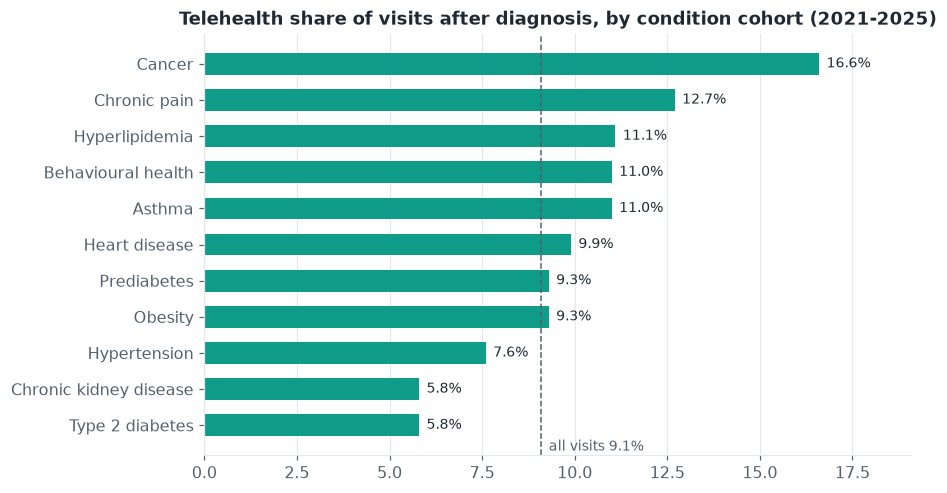

In [8]:
fig, ax = plt.subplots(figsize=(8.5, 4.6))
d = q3.sort_values("telehealth_share_pct")
bars = ax.barh(d.condition_group, d.telehealth_share_pct, color=TEAL, height=0.6)
ax.axvline(d.overall_share_pct.iloc[0], color=MUTED, lw=1, ls="--")
ax.text(d.overall_share_pct.iloc[0] + 0.2, -0.7, f"all visits {d.overall_share_pct.iloc[0]:.1f}%", color=MUTED, fontsize=9)
for b, v, n in zip(bars, d.telehealth_share_pct, d.visits_per_patient):
    ax.text(v + 0.2, b.get_y() + b.get_height() / 2, f"{v:.1f}%", va="center", color=INK, fontsize=9)
ax.set_title("Telehealth share of visits after diagnosis, by condition cohort (2021-2025)")
ax.set_xlim(0, d.telehealth_share_pct.max() * 1.15); ax.grid(axis="y", visible=False)
finish(fig, "03_adoption_by_condition.png")

Cancer, chronic pain and behavioural-health cohorts lean virtual: their care is heavy on medication review and
symptom check-ins. Type 2 diabetes and chronic kidney disease sit *below* the average even though three-quarters of
those patients have used telehealth, because their visit volume is dominated by hands-on care (dialysis, foot and eye
checks, labs) that dilutes the share. The right metric for those cohorts is telehealth share of *eligible* visits,
not of all visits.

## 4. What telehealth is used for

`04_visit_reasons_by_modality.sql` — `ROW_NUMBER() OVER (PARTITION BY modality)` for a top-8 per modality and
`SUM() OVER (PARTITION BY modality)` for the within-modality share.

In [9]:
q4 = run("04_visit_reasons_by_modality")
q4.pivot_table(index="rank_in_modality", columns="modality", values=["reason", "pct_of_modality"], aggfunc="first")

pct_of_modality                                                        reason                                         
modality               in_person telehealth                                          in_person                               telehealth
rank_in_modality                                                                                                                       
1                           14.2       15.4          Chronic kidney disease stage 4 (disorder)          Dependent drug abuse (disorder)
2                           13.4       10.5         General examination of patient (procedure)       Encounter for check up (procedure)
3                            7.5        8.2                       Well child visit (procedure)                Hyperlipidemia (disorder)
4                            6.6        7.9                         Normal pregnancy (finding)               Viral sinusitis (disorder)
5                            6.0        6.5       Patient referral for dental care (procedure)      Contraception care (regime/therapy)
6                            5.9        4.7                Contraception care (regime/therapy)  Malignant neoplasm of breast (disorder)
7                            5.8        4.6  Administration of vaccine to produce active im...       Acute viral pharyngitis (disorder)
8                            5.8        4.4                              Gingivitis (disorder)              Acute bronchitis (disorder)

Virtual visits concentrate on medication-assisted treatment for substance use, routine check-ups, lipid management,
contraception and minor acute illness (sinusitis, pharyngitis, bronchitis). In-person volume is led by physicals,
dialysis, well-child care, pregnancy and immunisations: the visits that will never move online.

## 5. No-show rates and what drives them

`05_no_show_rates.sql` compares each age group x modality cell with its modality total, its age-group total and the
overall rate, all with `SUM() OVER (PARTITION BY ...)`. `06_no_show_drivers.sql` unpivots booking lead time,
weekday and visit category into one long table with in-person and telehealth rates side by side.

In [10]:
q5 = run("05_no_show_rates")
q5

,age_group,modality,booked,completed,no_shows,cancelled,no_show_rate_pct,cancel_rate_pct,modality_no_show_rate_pct,age_group_no_show_rate_pct,diff_vs_overall_pts
0,0-17,in_person,5652,4502,866,284,15.3,5.0,15.1,14.8,0.8
1,0-17,telehealth,330,302,19,9,5.8,2.7,8.0,14.8,-8.7
2,18-34,in_person,8766,6516,1840,410,21.0,4.7,15.1,20.1,6.5
3,18-34,telehealth,926,785,104,37,11.2,4.0,8.0,20.1,-3.3
4,35-49,in_person,6550,5124,1079,347,16.5,5.3,15.1,15.7,2.0
5,35-49,telehealth,769,668,69,32,9.0,4.2,8.0,15.7,-5.5
6,50-64,in_person,7815,6466,927,422,11.9,5.4,15.1,11.4,-2.6
7,50-64,telehealth,772,690,48,34,6.2,4.4,8.0,11.4,-8.3
8,65+,in_person,7430,6238,768,424,10.3,5.7,15.1,9.9,-4.2
9,65+,telehealth,708,635,39,34,5.5,4.8,8.0,9.9,-9.0


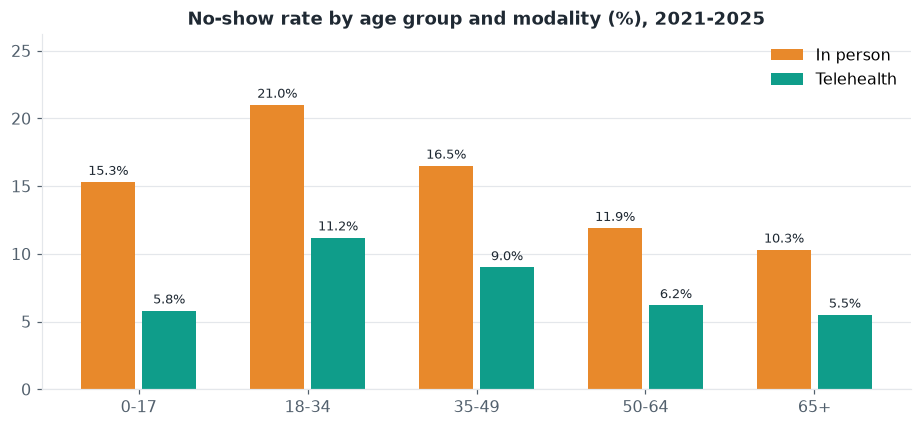

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4))
x = np.arange(len(AGE_ORDER)); w = 0.36
for i, mod in enumerate(["in_person", "telehealth"]):
    d = q5[q5.modality == mod].set_index("age_group").loc[AGE_ORDER]
    bars = ax.bar(x + (i - 0.5) * w, d.no_show_rate_pct, width=w - 0.04, color=MODALITY_COLORS[mod], label=MODALITY_LABELS[mod])
    for b, v in zip(bars, d.no_show_rate_pct):
        ax.text(b.get_x() + b.get_width() / 2, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", color=INK, fontsize=8.5)
ax.set_xticks(x, AGE_ORDER); ax.set_title("No-show rate by age group and modality (%), 2021-2025")
ax.set_ylim(0, q5.no_show_rate_pct.max() * 1.25); ax.grid(axis="x", visible=False); ax.legend(loc="upper right")
finish(fig, "04_no_show_by_age.png")

In [12]:
q6 = run("06_no_show_drivers")
q6

,driver,level,booked_in_person,no_show_rate_in_person_pct,booked_telehealth,no_show_rate_telehealth_pct,telehealth_advantage_pts,risk_rank_within_driver
0,Booking lead time,31+ days,9024,18.4,342,10.5,7.9,1
1,Booking lead time,15-30 days,9219,15.9,755,9.5,6.4,2
2,Booking lead time,4-14 days,13878,13.6,1480,7.4,6.3,3
3,Booking lead time,0-3 days,4092,11.3,928,6.7,4.6,4
4,Visit category,outpatient,6461,14.5,674,8.5,6.1,1
5,Visit category,ambulatory,21150,14.3,2831,7.8,6.5,2
6,Weekday,Tue,4849,16.4,468,7.7,8.7,1
7,Weekday,Mon,5366,16.0,507,11.0,5.0,2
8,Weekday,Wed,4935,15.8,473,7.0,8.8,3
9,Weekday,Fri,5740,15.5,517,7.5,8.0,4


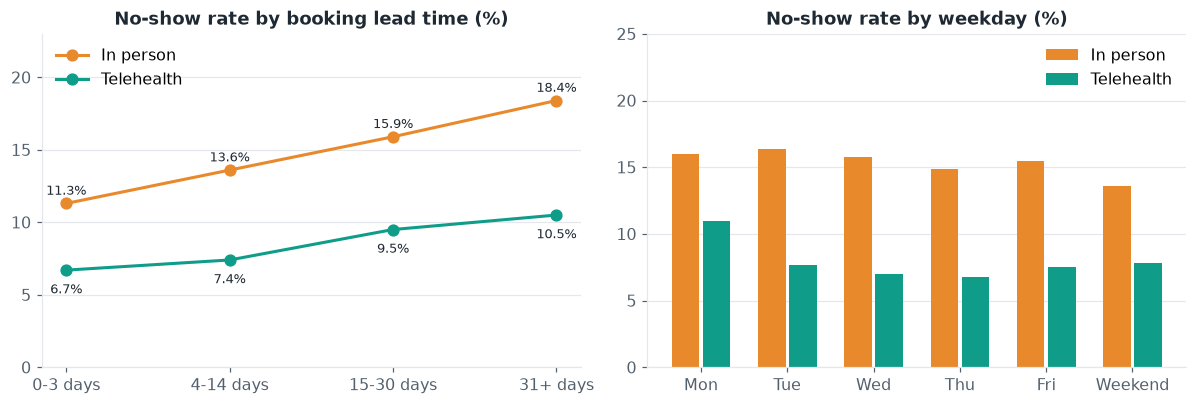

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
lead_order = ["0-3 days", "4-14 days", "15-30 days", "31+ days"]
d = q6[q6.driver == "Booking lead time"].set_index("level").loc[lead_order]
ax = axes[0]
ax.plot(lead_order, d.no_show_rate_in_person_pct, color=ORANGE, lw=2, marker="o", ms=7, label="In person")
ax.plot(lead_order, d.no_show_rate_telehealth_pct, color=TEAL, lw=2, marker="o", ms=7, label="Telehealth")
for xx, v in zip(lead_order, d.no_show_rate_in_person_pct):
    ax.text(xx, v + 0.6, f"{v:.1f}%", ha="center", color=INK, fontsize=8.5)
for xx, v in zip(lead_order, d.no_show_rate_telehealth_pct):
    ax.text(xx, v - 1.6, f"{v:.1f}%", ha="center", color=INK, fontsize=8.5)
ax.set_title("No-show rate by booking lead time (%)"); ax.set_ylim(0, d.no_show_rate_in_person_pct.max() * 1.25)
ax.legend(loc="upper left"); ax.grid(axis="x", visible=False)

wd_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Weekend"]
d = q6[q6.driver == "Weekday"].set_index("level").loc[wd_order]
ax = axes[1]; x = np.arange(len(wd_order)); w = 0.36
ax.bar(x - w / 2, d.no_show_rate_in_person_pct, width=w - 0.04, color=ORANGE, label="In person")
ax.bar(x + w / 2, d.no_show_rate_telehealth_pct, width=w - 0.04, color=TEAL, label="Telehealth")
ax.set_xticks(x, wd_order); ax.set_title("No-show rate by weekday (%)"); ax.set_ylim(0, 25)
ax.legend(loc="upper right"); ax.grid(axis="x", visible=False)
finish(fig, "05_no_show_drivers.png")

Telehealth roughly halves the no-show rate in every age band, and the gap is widest where in-person no-shows are
worst: young adults (21% in person vs 11% virtual). Booking lead time is the strongest operational lever: in-person
bookings made more than a month out are missed 18% of the time versus 11% for same-week slots. Weekday makes
little difference once lead time is accounted for.

## 6. Follow-up after an emergency or inpatient discharge

`07_post_acute_followup.sql` — a self-join of `encounters` on itself, `ROW_NUMBER() OVER (PARTITION BY discharge)`
to keep the first ambulatory, outpatient, wellness or virtual visit after each discharge, and a `LEFT JOIN` so
discharges with no follow-up stay in the denominator. This is the classic transitions-of-care measure.

In [14]:
q7 = run("07_post_acute_followup")
q7

,index_class,age_group,discharges,followup_7d_pct,followup_14d_pct,followup_30d_pct,avg_days_to_followup,telehealth_share_of_30d_followups_pct
0,emergency,0-17,229,17.5,23.1,30.1,9.0,18.8
1,emergency,18-34,429,10.5,14.9,24.5,12.1,38.1
2,emergency,35-49,324,9.0,17.0,26.5,12.8,20.9
3,emergency,50-64,271,9.6,22.9,39.1,15.0,18.9
4,emergency,65+,337,10.7,24.6,44.5,15.5,10.7
5,inpatient,18-34,27,11.1,18.5,25.9,10.9,14.3
6,inpatient,35-49,80,6.3,17.5,25.0,11.3,25.0
7,inpatient,50-64,79,11.4,27.8,44.3,12.4,20.0
8,inpatient,65+,141,11.3,30.5,37.6,10.7,9.4


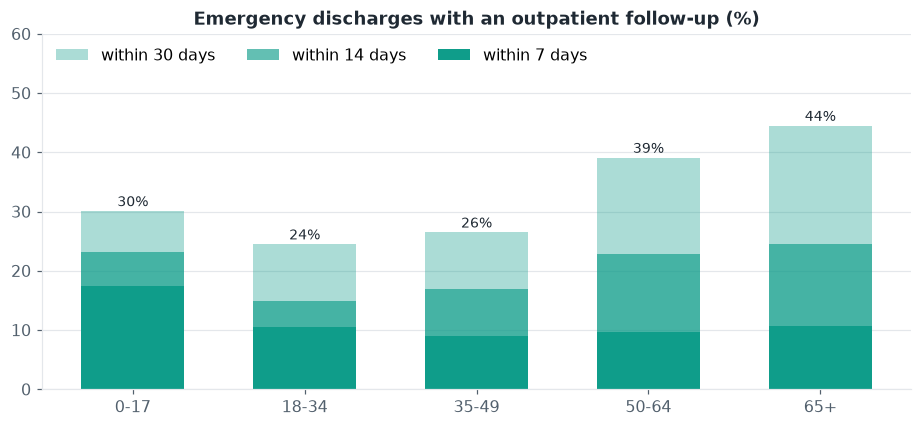

In [15]:
fig, ax = plt.subplots(figsize=(8.5, 4))
d = q7[q7.index_class == "emergency"].set_index("age_group").loc[AGE_ORDER]
x = np.arange(len(AGE_ORDER))
ax.bar(x, d.followup_30d_pct, color=TEAL, alpha=0.35, width=0.6, label="within 30 days")
ax.bar(x, d.followup_14d_pct, color=TEAL, alpha=0.65, width=0.6, label="within 14 days")
ax.bar(x, d.followup_7d_pct, color=TEAL, width=0.6, label="within 7 days")
for xx, v in zip(x, d.followup_30d_pct):
    ax.text(xx, v + 0.8, f"{v:.0f}%", ha="center", color=INK, fontsize=9)
ax.set_xticks(x, AGE_ORDER); ax.set_ylim(0, 60); ax.grid(axis="x", visible=False)
ax.set_title("Emergency discharges with an outpatient follow-up (%)"); ax.legend(loc="upper left", ncol=3)
finish(fig, "06_post_ed_followup.png")

Fewer than half of emergency discharges are followed by any outpatient contact within 30 days, and only about one
in ten within a week. Adults aged 18-49 are the weakest group at roughly 25%, well below the 65+ group at 45%.
Where follow-up does happen, telehealth already delivers a fifth to a third of it in the working-age bands, which
makes a virtual post-discharge check-in the obvious lever for closing the gap.

## 7. Chronic-care cadence

`08_chronic_care_cadence.sql` — `LAG()` over each patient's visits gives the gap between consecutive visits; the
longest gap decides whether a patient stayed on a six-month cadence through 2023-2025. Exposure (telehealth use)
is measured in the *prior* two years so it precedes the outcome.

In [16]:
q8 = run("08_chronic_care_cadence")
q8

,condition_group,user_type,patients,visits_per_patient_year,avg_gap_between_visits_days,pct_with_no_visits,pct_on_6_month_cadence
0,Asthma,in-person only,30,5.6,97.0,0.0,20.0
1,Asthma,prior telehealth user,53,5.7,79.0,0.0,26.4
2,Behavioural health,in-person only,42,3.8,148.0,0.0,9.5
3,Behavioural health,prior telehealth user,62,10.7,94.0,0.0,32.3
4,Chronic kidney disease,in-person only,14,14.8,71.0,0.0,57.1
5,Chronic kidney disease,prior telehealth user,60,25.7,46.0,0.0,58.3
6,Heart disease,in-person only,80,3.2,133.0,0.0,8.8
7,Heart disease,prior telehealth user,92,9.4,86.0,0.0,28.3
8,Hypertension,in-person only,112,4.2,138.0,0.0,12.5
9,Hypertension,prior telehealth user,144,11.4,89.0,0.0,29.2


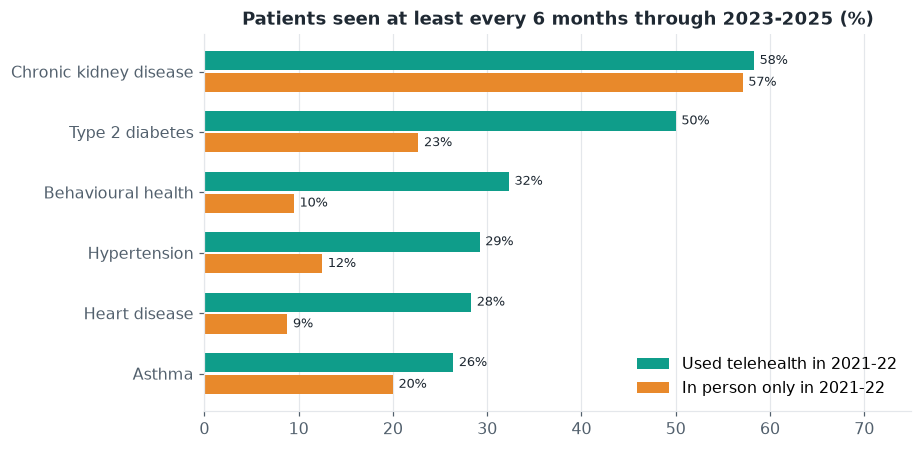

In [17]:
fig, ax = plt.subplots(figsize=(8.5, 4.2))
d = q8.pivot(index="condition_group", columns="user_type", values="pct_on_6_month_cadence").sort_values("prior telehealth user")
y = np.arange(len(d)); h = 0.36
ax.barh(y + h / 2, d["prior telehealth user"], height=h - 0.04, color=TEAL, label="Used telehealth in 2021-22")
ax.barh(y - h / 2, d["in-person only"], height=h - 0.04, color=ORANGE, label="In person only in 2021-22")
for yy, v in zip(y + h / 2, d["prior telehealth user"]):
    ax.text(v + 0.6, yy, f"{v:.0f}%", va="center", color=INK, fontsize=8.5)
for yy, v in zip(y - h / 2, d["in-person only"]):
    ax.text(v + 0.6, yy, f"{v:.0f}%", va="center", color=INK, fontsize=8.5)
ax.set_yticks(y, d.index); ax.set_xlim(0, 75); ax.grid(axis="y", visible=False)
ax.set_title("Patients seen at least every 6 months through 2023-2025 (%)"); ax.legend(loc="lower right")
finish(fig, "07_chronic_cadence.png")

Across every condition, patients who had already used telehealth were two to three times more likely to stay on a
six-month cadence and had visit gaps a month or two shorter. This is an association, not a treatment effect:
frequent attenders are more likely to have tried telehealth in the first place. It does show that the virtual
channel is where the engaged chronic patients already are, and that the in-person-only group is the one to target.

## 8. Engagement by age group and condition

`09_engagement_by_age_and_condition.sql` — patient-level features from three tables (visits per year, appointment
completion rate, telehealth share), `NTILE(4)` to place each patient in an engagement quartile, then a cell-level
summary for every age group x condition combination with at least 10 patients.

In [18]:
q9 = run("09_engagement_by_age_and_condition")
q9

,age_group,condition_group,patients,visits_per_patient_year,appointment_completion_pct,telehealth_share_pct,pct_in_top_engagement_quartile,pct_in_bottom_engagement_quartile
0,0-17,Asthma,22,5.1,88.1,11.8,22.7,13.6
1,18-34,Asthma,28,6.2,83.2,18.5,60.7,3.6
2,35-49,Asthma,13,4.0,82.1,13.8,15.4,0.0
3,50-64,Asthma,10,5.1,90.7,16.0,30.0,20.0
4,65+,Asthma,10,8.2,89.6,9.6,40.0,0.0
5,18-34,Behavioural health,28,4.5,80.9,13.6,28.6,39.3
6,35-49,Behavioural health,12,10.0,81.0,20.6,16.7,41.7
7,50-64,Behavioural health,32,7.7,92.1,7.8,18.8,31.3
8,65+,Behavioural health,24,11.2,92.5,8.5,41.7,12.5
9,50-64,Heart disease,45,6.0,89.8,8.5,17.8,26.7


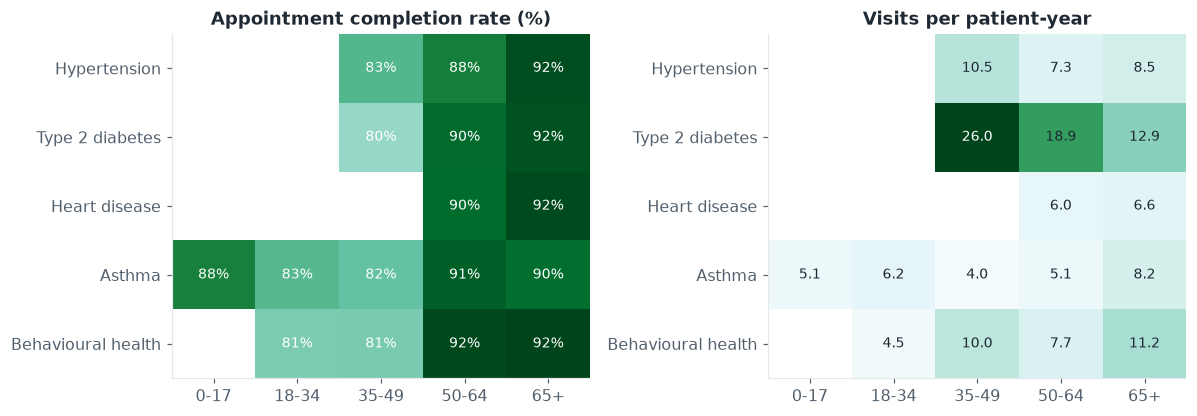

In [19]:
cond_order = ["Hypertension", "Type 2 diabetes", "Heart disease", "Asthma", "Behavioural health"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.9))
for ax, col, title, fmt in [(axes[0], "appointment_completion_pct", "Appointment completion rate (%)", "{:.0f}%"),
                            (axes[1], "visits_per_patient_year", "Visits per patient-year", "{:.1f}")]:
    m = q9.pivot(index="condition_group", columns="age_group", values=col).reindex(index=cond_order, columns=AGE_ORDER)
    im = ax.imshow(m.values, cmap="BuGn", aspect="auto", vmin=np.nanmin(m.values) * 0.9, vmax=np.nanmax(m.values))
    ax.set_xticks(range(len(AGE_ORDER)), AGE_ORDER); ax.set_yticks(range(len(cond_order)), cond_order)
    ax.grid(False); ax.set_title(title)
    for i in range(m.shape[0]):
        for j in range(m.shape[1]):
            v = m.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, fmt.format(v), ha="center", va="center", fontsize=9,
                        color="white" if v > np.nanmax(m.values) * 0.85 else INK)
finish(fig, "08_engagement_heatmap.png")

Two patterns hold across conditions: appointment completion rises steadily with age (about 80% for patients
under 35, over 90% at 65+), and visit intensity is highest in type 2 diabetes and lowest in asthma. Young adults
with behavioural-health or asthma diagnoses are the least engaged cells on both measures, and also the cells where
telehealth share is highest, so they are the natural pilot population for virtual-first care pathways.

## 9. Do first-time telehealth users come back?

`10_telehealth_persistence.sql` — `ROW_NUMBER()` finds each patient's first virtual visit and `LEAD()` the next
one; cohorts are defined by the year of that first visit and followed for 12 months.

In [20]:
q10 = run("10_telehealth_persistence")
q10

,cohort_year,first_time_users,pct_repeat_within_12m,avg_days_to_second_visit,telehealth_share_of_next_12m_visits_pct,pct_with_no_visit_of_any_kind_next_12m
0,2019,32,46.9,193.0,10.4,3.1
1,2020,420,47.1,132.0,18.3,3.1
2,2021,213,40.8,137.0,17.1,3.3
3,2022,125,26.4,115.0,14.4,8.8
4,2023,92,26.1,122.0,12.2,3.3
5,2024,76,23.7,127.0,15.0,10.5


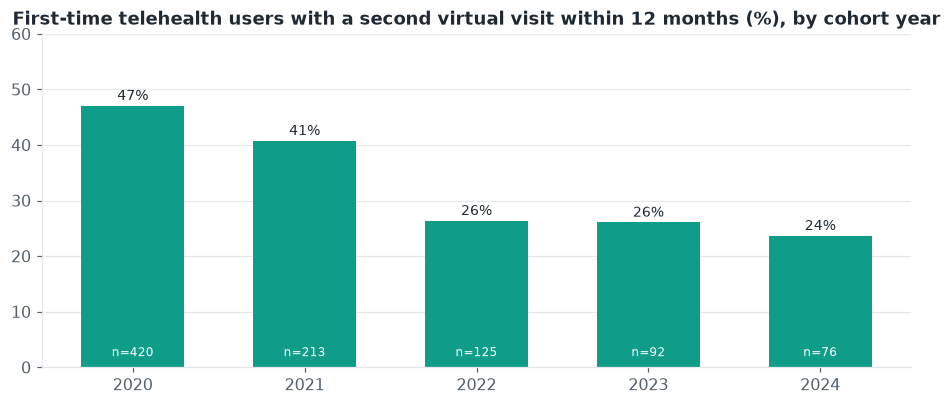

In [21]:
fig, ax = plt.subplots(figsize=(8.5, 3.8))
d = q10[q10.cohort_year >= 2020]
bars = ax.bar(d.cohort_year.astype(str), d.pct_repeat_within_12m, color=TEAL, width=0.6)
for b, v, n in zip(bars, d.pct_repeat_within_12m, d.first_time_users):
    ax.text(b.get_x() + b.get_width() / 2, v + 1, f"{v:.0f}%", ha="center", color=INK, fontsize=9)
    ax.text(b.get_x() + b.get_width() / 2, 2, f"n={n}", ha="center", color="white", fontsize=8)
ax.set_ylim(0, 60); ax.grid(axis="x", visible=False)
ax.set_title("First-time telehealth users with a second virtual visit within 12 months (%), by cohort year")
finish(fig, "09_persistence.png")

Retention has fallen with each cohort: almost half of the 2020 first-timers returned for a second virtual visit
within a year, against a quarter of those who started in 2022 or later. Early adopters were pushed by necessity and
tended to be regular attenders; later first-timers try telehealth once for a minor complaint and drift back to
in-person care. Growing telehealth now means converting second visits, not first ones.

## 10. Summary

| Theme | Finding | Implication |
|---|---|---|
| Adoption | Telehealth settled at ~9% of all visits (about a third of eligible visit types); 68% of patients have used it | The channel is mainstream; growth now comes from repeat use, not first use |
| Age | Reach is flat across adult age bands; intensity peaks at 18-49 | Do not treat 65+ as non-adopters, design for lower-intensity use |
| Condition | Behavioural health, cancer and chronic pain lean virtual; diabetes and CKD are diluted by hands-on care | Measure telehealth share of *eligible* visits per condition |
| No-shows | Virtual visits halve the no-show rate (8% vs 15%); long lead times and young adults are the risk | Offer a virtual slot to any in-person booking >2 weeks out for under-35s |
| Follow-up | <45% of emergency discharges see a clinician within 30 days; 18-49 year olds ~25% | Virtual 7-day post-discharge check-in |
| Cadence | Prior telehealth users are 2-3x more likely to stay on a six-month chronic-care cadence | Target the in-person-only chronic cohort for outreach |
| Persistence | Second-visit conversion fell from 47% (2020 cohort) to ~25% (2022+) | Book the next virtual visit before the first one ends |

In [22]:
con.close()